In [13]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import(accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,roc_curve,auc)



In [15]:
#Load_dataset
data=load_breast_cancer()

X=data.data
Y=data.target

print("Dataset Shape:",X.shape)
print("Classes:",np.unique(Y))


Dataset Shape: (569, 30)
Classes: [0 1]


In [16]:
X_train,X_test,Y_train,Y_test=train_test_split(
X,Y,test_size=0.2,random_state=42,stratify=Y)

In [17]:
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

mle_model = LogisticRegression(
    penalty= None,
    max_iter=5000,
    random_state=42
)

mle_model.fit(X_train,Y_train)

Y_pred_mle=mle_model.predict(X_test)

In [18]:
map_l2 = LogisticRegression(
    penalty='l2',
    C=1.0,
    solver='lbfgs',
    max_iter=5000,
    random_state=42
)
map_l2.fit(X_train,Y_train)
Y_pred_l2=map_l2.predict(X_test)

In [19]:
map_l1 = LogisticRegression(
    penalty='l1',
    solver='liblinear',
    C=1.0,
    max_iter=5000,
    random_state=42
) 
map_l1.fit(X_train,Y_train)
Y_pred_l1 = map_l1.predict(X_test)

In [20]:
def evaluate(model_name,Y_true,Y_pred):

    print("\n",'='*40)
    print(model_name)
    print("="*40)

    print("Accuracy :",accuracy_score(Y_true,Y_pred))
    print("Precision:", precision_score(Y_true,Y_pred))
    print("Recall:",recall_score(Y_true,Y_pred)) 
    print("F1 score:",f1_score(Y_true,Y_pred))

    print("\nConfusionMatrix")
    print(confusion_matrix(Y_true,Y_pred))
          
                
        
    



In [21]:
evaluate("MLE",Y_test,Y_pred_mle)
evaluate("MAP(L2)",Y_test,Y_pred_l2)
evaluate("MAP(L1)",Y_test,Y_pred_l1)


MLE
Accuracy : 0.9210526315789473
Precision: 0.9701492537313433
Recall: 0.9027777777777778
F1 score: 0.935251798561151

ConfusionMatrix
[[40  2]
 [ 7 65]]

MAP(L2)
Accuracy : 0.9824561403508771
Precision: 0.9861111111111112
Recall: 0.9861111111111112
F1 score: 0.9861111111111112

ConfusionMatrix
[[41  1]
 [ 1 71]]

MAP(L1)
Accuracy : 0.9912280701754386
Precision: 0.9863013698630136
Recall: 1.0
F1 score: 0.993103448275862

ConfusionMatrix
[[41  1]
 [ 0 72]]


In [22]:
print("Number of Zero Coefficients")
print("MLE  :",np.sum(mle_model.coef_[0] == 0))
print("MAP L2  :",np.sum(map_l2.coef_[0] == 0))
print("MAP L1  :",np.sum(map_l1.coef_[0] == 0))

Number of Zero Coefficients
MLE  : 0
MAP L2  : 0
MAP L1  : 14


In [23]:
results = pd.DataFrame(columns=["Model","Accuracy","precision","Recall","F1 Score"])
models = [("MLE",mle_model,Y_pred_mle),("MAP L2",map_l2,Y_pred_l2),("MAP L1",map_l1,Y_pred_l1)]
for name,model,pred in models:
    results.loc[len(results)] = [name,accuracy_score(Y_test,pred),precision_score(Y_test,pred),recall_score(Y_test,pred),f1_score(Y_test,pred)]
print(results)

    Model  Accuracy  precision    Recall  F1 Score
0     MLE  0.921053   0.970149  0.902778  0.935252
1  MAP L2  0.982456   0.986111  0.986111  0.986111
2  MAP L1  0.991228   0.986301  1.000000  0.993103


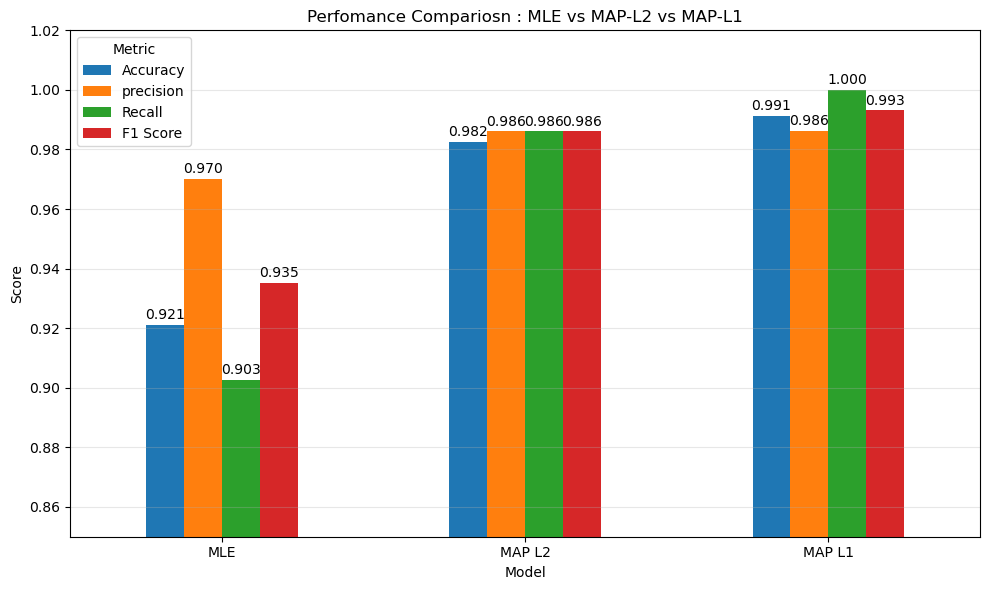

In [24]:
ax=results.set_index("Model").plot(
    kind="bar",
    figsize=(10,6)
)
plt.title("Perfomance Compariosn : MLE vs MAP-L2 vs MAP-L1")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0.85,1.02)
plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.grid(axis="y",alpha=0.3)

#show values on bars
for container in ax.containers:
     ax.bar_label(container,fmt="%.3f",padding=2)
plt.tight_layout()
plt.show()

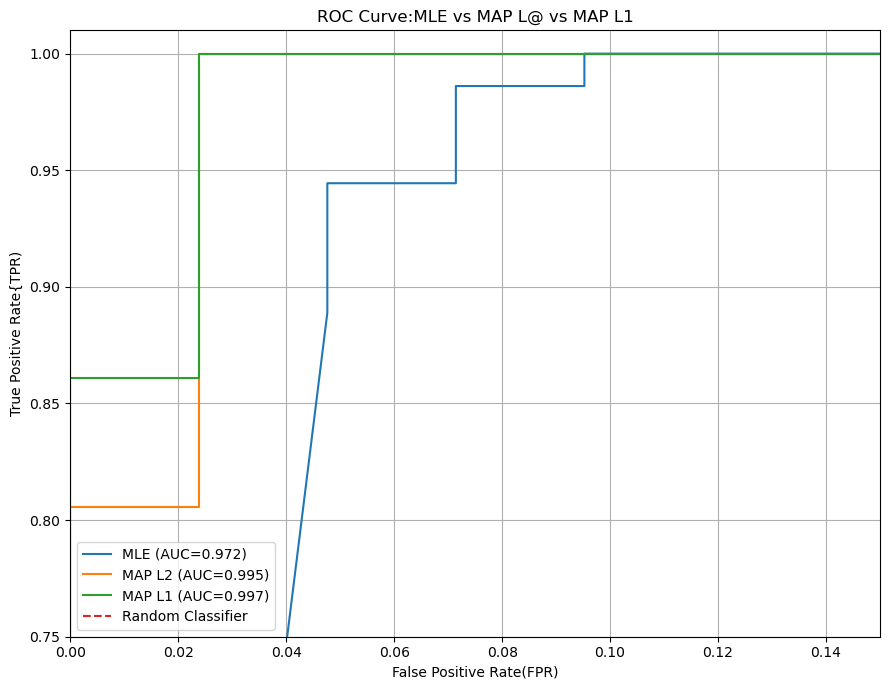

In [27]:
plt.figure(figsize=(9,7))
for name,model,pred in models:
     #Predicted probability for positive class
    Y_prob=model.predict_proba(X_test)[:,1]
    #Calculated ROC values
    fpr,tpr,thresholds=roc_curve(Y_test, Y_prob)
    #Calculated AUC
    roc_auc = auc(fpr, tpr)
    #Plot ROC curve
    plt.plot(fpr,tpr,label=f"{name} (AUC={roc_auc:.3f})")
    #Random classifier reference line
plt.plot([0,1],[0,1],linestyle="--",label="Random Classifier")
#Zoom into the useful region 
plt.xlim(0,0.15)
plt.ylim(0.75,1.01)
plt.xlabel("False Positive Rate(FPR)")
plt.ylabel("True Positive Rate{TPR)")
plt.title("ROC Curve:MLE vs MAP L@ vs MAP L1")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()